In [2]:
!pwd
!ls -al ~/work

/home/jovyan
total 2840
drwxrwsr-x 14 root   users    4096 Jun 12 07:15 .
drwsrws---  1 jovyan users    4096 Jun 12 07:14 ..
drwxrwsr-x  2 jovyan users    4096 Jun 12 07:15 .ipynb_checkpoints
drwxrwsr-x  4 jovyan users    4096 Jun 12 07:15 data
drwxrwsr-x  5 jovyan users    4096 Jun 10 03:37 data_augmentation
drwxrwsr-x  3 jovyan users    4096 May 15 05:24 data_preprocess
drwxrwsr-x  5 jovyan users    4096 Jun  2 00:43 human_segmentation
-rw-rw-r--  1 jovyan users 2831720 Jun  5 03:32 human_segmentation_cat.ipynb
drwxrws---  2 root   users   16384 May 11 05:13 lost+found
drwxrwsr-x  2 jovyan users    4096 May 18 06:01 pokemon
drwxrwsr-x  3 jovyan users    4096 May 18 07:08 pokemon_eda
drwxrwsr-x  4 jovyan users    4096 May 15 08:18 project
drwxr-sr-x  3 jovyan users    4096 Jun 12 06:47 sentiment_classification
drwxrwsr-x  2 jovyan users    4096 Jun 11 01:44 word_embedding
drwxrwsr-x  4 jovyan users    4096 Jun  2 08:06 workplace


In [3]:
!mkdir -p ~/work/sentiment_classification
!ls -al ~/work

total 2840
drwxrwsr-x 14 root   users    4096 Jun 12 07:15 .
drwsrws---  1 jovyan users    4096 Jun 12 07:14 ..
drwxrwsr-x  2 jovyan users    4096 Jun 12 07:15 .ipynb_checkpoints
drwxrwsr-x  4 jovyan users    4096 Jun 12 07:15 data
drwxrwsr-x  5 jovyan users    4096 Jun 10 03:37 data_augmentation
drwxrwsr-x  3 jovyan users    4096 May 15 05:24 data_preprocess
drwxrwsr-x  5 jovyan users    4096 Jun  2 00:43 human_segmentation
-rw-rw-r--  1 jovyan users 2831720 Jun  5 03:32 human_segmentation_cat.ipynb
drwxrws---  2 root   users   16384 May 11 05:13 lost+found
drwxrwsr-x  2 jovyan users    4096 May 18 06:01 pokemon
drwxrwsr-x  3 jovyan users    4096 May 18 07:08 pokemon_eda
drwxrwsr-x  4 jovyan users    4096 May 15 08:18 project
drwxr-sr-x  3 jovyan users    4096 Jun 12 06:47 sentiment_classification
drwxrwsr-x  2 jovyan users    4096 Jun 11 01:44 word_embedding
drwxrwsr-x  4 jovyan users    4096 Jun  2 08:06 workplace


In [4]:
%cd ~/work/sentiment_classification
!pwd

/home/jovyan/work/sentiment_classification
/home/jovyan/work/sentiment_classification


In [5]:
!pip install gensim==4.3.2

In [6]:
!conda install scipy==1.12.0 numpy==1.26.3 -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [7]:
import numpy as np
import scipy
import gensim

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("gensim:", gensim.__version__)

numpy: 1.26.3
scipy: 1.12.0
gensim: 4.3.2


In [1]:
!ln -s /home/jovyan/data /home/jovyan/work/sentiment_classification/
!ls -al ~/work/sentiment_classification

ln: failed to create symbolic link '/home/jovyan/work/sentiment_classification/data': File exists
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [2]:
!ln -s /home/jovyan/data /home/jovyan/work/sentiment_classification/
!ls -al ~/work/sentiment_classification

ln: failed to create symbolic link '/home/jovyan/work/sentiment_classification/data': File exists
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [3]:
!ls -al ~/work/sentiment_classification/data

lrwxrwxrwx 1 jovyan users 17 Jun 12 03:35 /home/jovyan/work/sentiment_classification/data -> /home/jovyan/data


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("준비 완료!")
print("현재 작업 폴더:", os.getcwd())

준비 완료!
현재 작업 폴더: /home/jovyan


In [5]:
%cd ~/work/sentiment_classification
!pwd
!ls -al

/home/jovyan/work/sentiment_classification
/home/jovyan/work/sentiment_classification
total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [6]:
!ls -al ~/work/sentiment_classification/data/

total 1912058
-rw-rw-r-- 1 root users 1647046227 Jun 17  2025 GoogleNews-vectors-negative300.bin.gz
-rw-rw-r-- 1 root users    1247853 Jun 19  2025 imdb_word_to_index.pickle
-rw-rw-r-- 1 root users   13498767 Jun 17  2025 imdb_x_test.npy
-rw-rw-r-- 1 root users   13967480 Jun 17  2025 imdb_x_train.npy
-rw-rw-r-- 1 root users     200128 Jun 17  2025 imdb_y_test.npy
-rw-rw-r-- 1 root users     200128 Jun 17  2025 imdb_y_train.npy
-rw-rw-r-- 1 root users    4893335 Jun 17  2025 ratings_test.txt
-rw-rw-r-- 1 root users   14628807 Jun 17  2025 ratings_train.txt
-rw-rw-r-- 1 root users   19893395 Jun 17  2025 word2vec_ko.model
-rw-rw-r-- 1 root users  121184128 Jun 17  2025 word2vec_ko.model.trainables.syn1neg.npy
-rw-rw-r-- 1 root users  121184128 Jun 17  2025 word2vec_ko.model.wv.vectors.npy


In [7]:
import os
import numpy as np

data_dir = os.path.join(os.getenv('HOME'), 'work/sentiment_classification/data/')

x_train = np.load(data_dir + 'imdb_x_train.npy', allow_pickle=True)
y_train = np.load(data_dir + 'imdb_y_train.npy', allow_pickle=True)
x_test = np.load(data_dir + 'imdb_x_test.npy', allow_pickle=True)
y_test = np.load(data_dir + 'imdb_y_test.npy', allow_pickle=True)

print(f"훈련 샘플 개수: {len(x_train)}")
print(f"테스트 샘플 개수: {len(x_test)}")
print(f"훈련 라벨 개수: {len(y_train)}")
print(f"테스트 라벨 개수: {len(y_test)}")

훈련 샘플 개수: 25000
테스트 샘플 개수: 25000
훈련 라벨 개수: 25000
테스트 라벨 개수: 25000


In [8]:
print(x_train[0])
print('라벨:', y_train[0])
print('1번째 리뷰 문장 길이:', len(x_train[0]))
print('2번째 리뷰 문장 길이:', len(x_train[1]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
라벨: 1
1번째 리뷰 문장 길이: 218
2번째 리뷰 문장 길이: 189


In [9]:
!ls ~/work/sentiment_classification/data/ | grep imdb

imdb_word_to_index.pickle
imdb_x_test.npy
imdb_x_train.npy
imdb_y_test.npy
imdb_y_train.npy


In [10]:
word_to_index = np.load(data_dir + 'imdb_word_to_index.pickle', allow_pickle=True)
index_to_word = {index: word for word, index in word_to_index.items()}

print(index_to_word[1])
print(word_to_index['the'])

the
1


In [11]:
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(
        index_to_word[index] if index in index_to_word else '<UNK>'
        for index in encoded_sentence[1:]
    )

print("decode 함수 준비 완료")

decode 함수 준비 완료


In [12]:
print(get_decoded_sentence(x_train[0], index_to_word))

as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other and in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then have two of

In [13]:
# 실제 인코딩 인덱스는 제공된 word_to_index에서 index 기준으로 3씩 뒤로 밀려 있습니다.
word_to_index = {k: (v + 3) for k, v in word_to_index.items()}

# 처음 몇 개 인덱스는 특수 토큰으로 정의합니다.
word_to_index["<PAD>"] = 0
word_to_index["<BOS>"] = 1
word_to_index["<UNK>"] = 2
word_to_index["<UNUSED>"] = 3

# 숫자에서 단어로 바꾸는 사전을 다시 만듭니다.
index_to_word = {index: word for word, index in word_to_index.items()}

print(index_to_word[1])
print(word_to_index['the'])
print(index_to_word[4])

<BOS>
4
the


In [14]:
print(get_decoded_sentence(x_train[0], index_to_word))
print('라벨:', y_train[0])

this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they h

In [15]:
total_data_text = list(x_train) + list(x_test)

num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print('문장길이 평균:', np.mean(num_tokens))
print('문장길이 최대:', np.max(num_tokens))
print('문장길이 표준편차:', np.std(num_tokens))

max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)

print('pad_sequences maxlen:', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens):.4f} 비율이 maxlen 설정값 이내에 포함됩니다.')

문장길이 평균: 234.75892
문장길이 최대: 2494
문장길이 표준편차: 172.91149458735703
pad_sequences maxlen: 580
전체 문장의 0.9454 비율이 maxlen 설정값 이내에 포함됩니다.


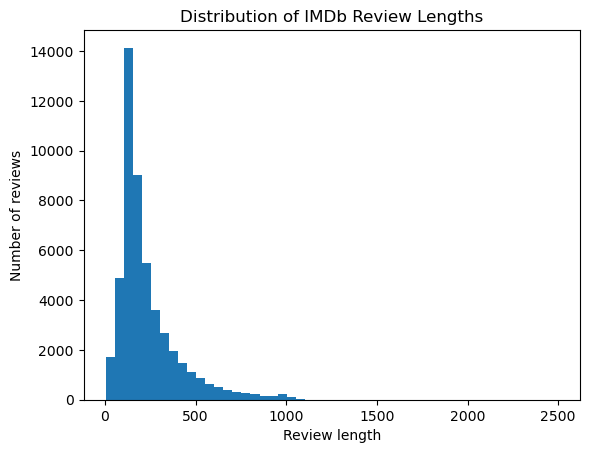

In [16]:
import matplotlib.pyplot as plt

plt.hist(num_tokens, bins=50)
plt.xlabel('Review length')
plt.ylabel('Number of reviews')
plt.title('Distribution of IMDb Review Lengths')
plt.show()

In [17]:
def pad_sequences(data, maxlen):
    padded_data = []
    
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = sentence + [0] * (maxlen - len(sentence))
        else:
            sentence = sentence[:maxlen]
        
        padded_data.append(sentence)
    
    return np.array(padded_data)

print("padding 함수 준비 완료")

padding 함수 준비 완료


In [18]:
x_train_padded = pad_sequences(x_train, maxlen)
x_test_padded = pad_sequences(x_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print("x_train_padded shape:", x_train_padded.shape)
print("x_test_padded shape:", x_test_padded.shape)
print("x_train_tensor shape:", x_train_tensor.shape)
print("x_test_tensor shape:", x_test_tensor.shape)

x_train_padded shape: (25000, 580)
x_test_padded shape: (25000, 580)
x_train_tensor shape: torch.Size([25000, 580])
x_test_tensor shape: torch.Size([25000, 580])


In [19]:
# 훈련 데이터 25,000개 중 앞의 10,000개를 검증 데이터로 사용합니다.
x_val = x_train_padded[:10000]
y_val = y_train[:10000]

# 나머지 15,000개를 실제 훈련 데이터로 사용합니다.
partial_x_train = x_train_padded[10000:]
partial_y_train = y_train[10000:]

print("partial_x_train shape:", partial_x_train.shape)
print("partial_y_train shape:", partial_y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

partial_x_train shape: (15000, 580)
partial_y_train shape: (15000,)
x_val shape: (10000, 580)
y_val shape: (10000,)


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000
word_vector_dim = 16

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SentimentModel(vocab_size, word_vector_dim)
print(model)

SentimentModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [21]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# numpy 배열을 torch tensor로 변환합니다.
partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

# x와 y를 하나의 데이터셋으로 묶습니다.
train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# batch 단위로 데이터를 꺼낼 수 있게 DataLoader를 만듭니다.
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("훈련 데이터 batch 개수:", len(train_loader))
print("검증 데이터 batch 개수:", len(val_loader))

훈련 데이터 batch 개수: 30
검증 데이터 batch 개수: 20


In [22]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.BCELoss()

print("optimizer:", optimizer)
print("loss function:", loss_fn)

optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
loss function: BCELoss()


In [23]:
epochs = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    # =========================
    # 1. Train 단계
    # =========================
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # =========================
    # 2. Validation 단계
    # =========================
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)

            val_loss += loss.item()

            predicted = (outputs.squeeze() > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f} - "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch 1/5 - Train Loss: 0.6930, Train Accuracy: 0.5083 - Validation Loss: 0.6942, Validation Accuracy: 0.5008
Epoch 2/5 - Train Loss: 0.6930, Train Accuracy: 0.4993 - Validation Loss: 0.6930, Validation Accuracy: 0.5011
Epoch 3/5 - Train Loss: 0.6928, Train Accuracy: 0.5093 - Validation Loss: 0.6932, Validation Accuracy: 0.5007
Epoch 4/5 - Train Loss: 0.6928, Train Accuracy: 0.5097 - Validation Loss: 0.6930, Validation Accuracy: 0.5013
Epoch 5/5 - Train Loss: 0.6927, Train Accuracy: 0.5067 - Validation Loss: 0.6934, Validation Accuracy: 0.5010


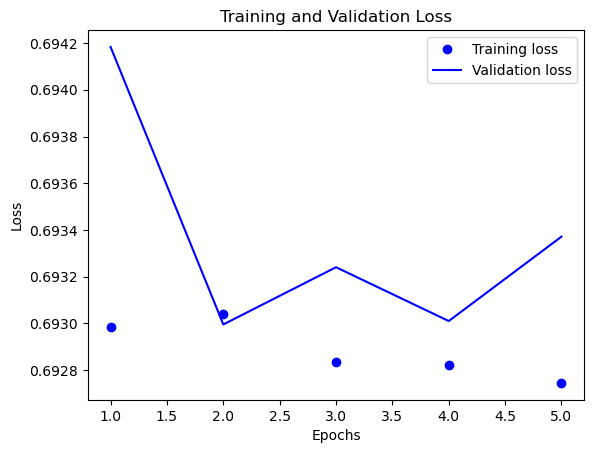

In [24]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

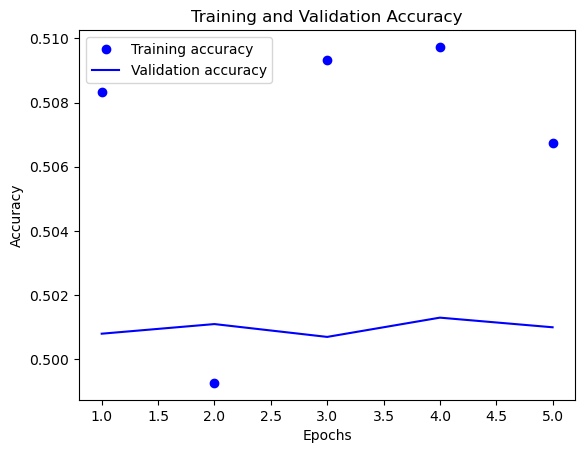

In [25]:
plt.clf()

plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accs, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        test_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.6933
Test Accuracy: 0.5032


1단계: 현재 결과가 낮은 이유 이해
2단계: 1-D CNN 모델로 먼저 바꿔보기
3단계: epoch를 5 → 10~15로 늘리기
4단계: loss/accuracy 그래프 확인
5단계: test accuracy 확인
6단계: 부족하면 LSTM pre-padding 또는 Word2Vec 적용

 퍼실님 중간 피드백에 맞춰
 현실적으로 0.8에 가까워질 가능성이 높은 1-D CNN 실험부터 시작하기!!!

1. 왜 지금 LSTM 정확도가 0.5일까?

현재 padding은 이런 방식이야.
실제 리뷰 단어들 + 0 + 0 + 0 + 0 ...
즉, post padding이야.

그런데 LSTM 모델은 마지막 시점만 사용했어.
x = x[:, -1, :]

문제는 마지막 시점이 실제 단어가 아니라 대부분 <PAD>, 즉 0일 수 있다는 거야.

그래서 모델이 리뷰의 진짜 감정 표현을 보기보다, 마지막의 패딩 정보를 보고 판단했을 가능성이 크다. 현재 LSTM은 문장 내용보다 padding의 영향을 많이 받아서 정확도가 0.5 근처에 머문 것으로 보인다.

2. 가장 먼저 추천하는 방법: 1-D CNN으로 바꾸기

1-D CNN은 LSTM처럼 마지막 단어만 보지 않아.
문장 전체를 훑으면서 중요한 표현을 찾아.

예를 들면:

really good
very boring
waste of time
highly recommend

이런 감성 표현을 필터가 잡아낼 수 있어.

그리고 post padding을 써도 LSTM보다 덜 치명적이야.
그래서 지금 상황에서는 1-D CNN이 더 빠르고 안정적인 개선 실험이야.

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000
word_vector_dim = 128

class CNNTextModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(CNNTextModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=0)
        
        self.conv1 = nn.Conv1d(
            in_channels=word_vector_dim,
            out_channels=128,
            kernel_size=7,
            padding=3
        )
        
        self.conv2 = nn.Conv1d(
            in_channels=128,
            out_channels=128,
            kernel_size=7,
            padding=3
        )
        
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)          # (batch, length, embedding_dim)
        x = x.permute(0, 2, 1)         # (batch, embedding_dim, length)
        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        x = self.global_max_pool(x).squeeze(2)  # (batch, 128)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        
        return x

model = CNNTextModel(vocab_size, word_vector_dim)
print(model)

CNNTextModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (conv1): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


Step 1. 기존 모델 대신 CNN 모델 만들기
작고 약한 LSTM 대신 문장 전체의 감성 표현을 찾는 1-D CNN 모델로 바꾼다.

In [28]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.BCELoss()

print("optimizer와 loss function 준비 완료")

optimizer와 loss function 준비 완료


Step 2. optimizer와 loss 다시 설정하기
새 모델을 만들었으면 optimizer도 반드시 새로 만들어야 한다.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

model = model.to(device)

사용 device: cuda


Step 3. 가능하면 GPU 사용 설정하기
모델을 GPU 또는 CPU로 보내서 학습 준비를 한다.

In [30]:
epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            predicted = (outputs > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f} - "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch 1/10 - Train Loss: 0.6925, Train Accuracy: 0.5211 - Validation Loss: 0.6841, Validation Accuracy: 0.6086
Epoch 2/10 - Train Loss: 0.6426, Train Accuracy: 0.6398 - Validation Loss: 0.5691, Validation Accuracy: 0.6988
Epoch 3/10 - Train Loss: 0.5097, Train Accuracy: 0.7577 - Validation Loss: 0.4723, Validation Accuracy: 0.7752
Epoch 4/10 - Train Loss: 0.3894, Train Accuracy: 0.8351 - Validation Loss: 0.4236, Validation Accuracy: 0.8047
Epoch 5/10 - Train Loss: 0.2868, Train Accuracy: 0.8909 - Validation Loss: 0.4182, Validation Accuracy: 0.8179
Epoch 6/10 - Train Loss: 0.2001, Train Accuracy: 0.9301 - Validation Loss: 0.4147, Validation Accuracy: 0.8287
Epoch 7/10 - Train Loss: 0.1349, Train Accuracy: 0.9585 - Validation Loss: 0.4794, Validation Accuracy: 0.8176
Epoch 8/10 - Train Loss: 0.0882, Train Accuracy: 0.9765 - Validation Loss: 0.4535, Validation Accuracy: 0.8399
Epoch 9/10 - Train Loss: 0.0440, Train Accuracy: 0.9913 - Validation Loss: 0.4872, Validation Accuracy: 0.8411
E

Step 4. CNN 모델 학습하기
CNN 모델을 10 epoch 정도 학습하면서 
validation accuracy가 0.8에 가까워지는지 확인한다.

Train Loss 감소
Validation Loss 감소
Train Accuracy 증가
Validation Accuracy 증가

In [32]:
test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        test_loss += loss.item()

        predicted = (outputs > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.5436
Test Accuracy: 0.8418


Step 5. 테스트셋 평가하기
새 CNN 모델이 실제 테스트셋에서 0.8 근처까지 올라가는지 확인한다.

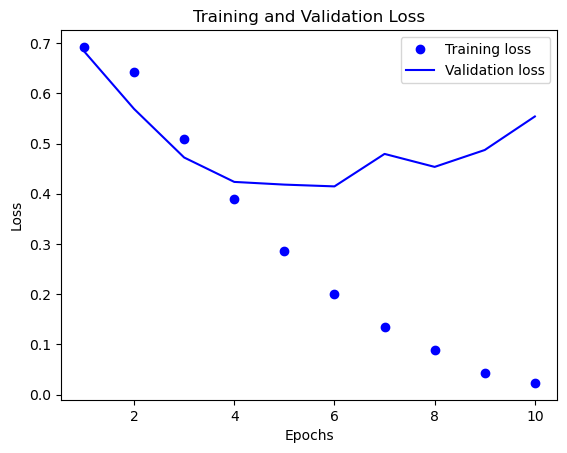

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

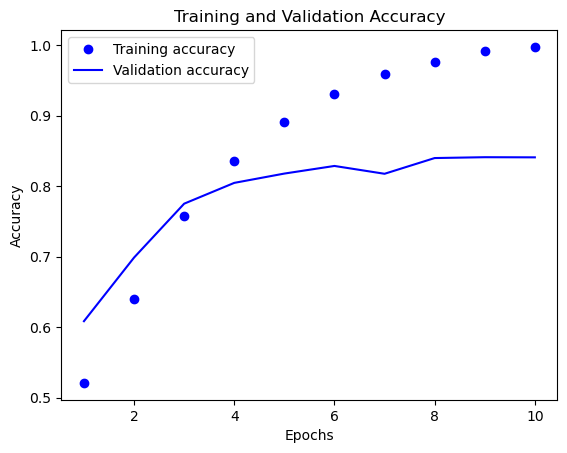

In [34]:
plt.clf()

plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accs, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

현재 CNN 모델은 LSTM보다 훨씬 잘 학습했고, validation accuracy가 약 0.84까지 올라갔으므로 Test Accuracy 0.8 목표를 달성할 가능성이 높다.

지금 바로 할 일: Test Accuracy 확인

In [35]:
test_dataset = TensorDataset(
    x_test_tensor,
    torch.tensor(y_test, dtype=torch.float32)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)

        test_loss += loss.item()

        predicted = (outputs > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.5436
Test Accuracy: 0.8418


기본 LSTM 모델은 Test Accuracy가 약 0.50 수준으로 낮게 나타났다. 이는 post-padding 이후 마지막 시점의 출력을 사용하는 구조에서 padding 정보가 모델 판단에 영향을 주었을 가능성이 있다. 이후 1-D CNN 모델로 변경하여 문장 전체에서 감성 표현 패턴을 추출하도록 설계한 결과, validation accuracy가 약 0.84까지 상승하였다. 따라서 텍스트 감성분석에서 RNN만이 유일한 선택지는 아니며, 1-D CNN도 효과적인 대안이 될 수 있음을 확인하였다.

1-D CNN 모델로 변경한 결과 Test Accuracy가 0.8418까지 상승하여, 목표였던 0.8 이상을 달성했다.

In [36]:
embedding_layer = model.embedding
weights = embedding_layer.weight.detach().cpu().numpy()

print("Embedding weight shape:", weights.shape)

Embedding weight shape: (10000, 128)


In [38]:
!mkdir -p ~/work/sentiment_classification/word2vec_emb
!ls -al ~/work/sentiment_classification

total 12
drwxr-sr-x  3 jovyan users 4096 Jun 12 06:47 .
drwxrwsr-x 14 root   users 4096 Jun 12 07:15 ..
lrwxrwxrwx  1 jovyan users   17 Jun 12 03:35 data -> /home/jovyan/data
drwxr-sr-x  2 jovyan users 4096 Jun 12 06:47 word2vec_emb


In [39]:
import os

word2vec_file_path = os.path.join(
    os.getenv('HOME'),
    'work/sentiment_classification/word2vec_emb/word2vec.txt'
)

with open(word2vec_file_path, 'w') as f:
    # 특수 토큰 4개를 제외하고 저장합니다.
    f.write('{} {}\n'.format(vocab_size - 4, word_vector_dim))

    vectors = model.embedding.weight.detach().cpu().numpy()

    for i in range(4, vocab_size):
        word = index_to_word.get(i, '<UNK>')
        vector_str = ' '.join(map(str, vectors[i, :]))
        f.write('{} {}\n'.format(word, vector_str))

print("저장 완료:", word2vec_file_path)

저장 완료: /home/jovyan/work/sentiment_classification/word2vec_emb/word2vec.txt


In [40]:
!ls -lh ~/work/sentiment_classification/word2vec_emb

total 14M
-rw-r--r-- 1 jovyan users 14M Jun 12 07:56 word2vec.txt


In [41]:
from gensim.models.keyedvectors import Word2VecKeyedVectors

word_vectors = Word2VecKeyedVectors.load_word2vec_format(
    word2vec_file_path,
    binary=False
)

print("불러오기 완료")
print("단어 개수:", len(word_vectors.key_to_index))
print("vector 크기:", word_vectors.vector_size)

불러오기 완료
단어 개수: 9996
vector 크기: 128


In [42]:
word_vectors.similar_by_word("love")

[('washed', 0.3334603011608124),
 ('traditions', 0.3046894669532776),
 ('schlock', 0.30207839608192444),
 ('length', 0.2873021364212036),
 ('communicate', 0.2861488461494446),
 ('travelling', 0.2776067554950714),
 ('find', 0.2714669108390808),
 ('stanwyck', 0.26767876744270325),
 ('plants', 0.26555752754211426),
 ('embrace', 0.2635810077190399)]

In [43]:
!ls -lh ~/work/sentiment_classification/data | grep -E "GoogleNews|word2vec|Word2Vec|ko"

In [44]:
!ls -lh ~/work/sentiment_classification/data

lrwxrwxrwx 1 jovyan users 17 Jun 12 03:35 /home/jovyan/work/sentiment_classification/data -> /home/jovyan/data


In [46]:
!find ~/work -name "sentiment_classification.ipynb"

/home/jovyan/work/data/sentiment_classification.ipynb


# 네이버 영화리뷰 감성분석 프로젝트

위쪽에서는 IMDB 영어 영화리뷰 감성분석 실습을 진행하였다.  
이제부터는 NSMC, 즉 네이버 영화리뷰 데이터를 활용하여 한국어 감성분석 프로젝트를 진행한다.

이번 프로젝트의 목표는 다음과 같다.

1. 한국어 텍스트를 머신러닝 입력용 숫자 데이터로 변환한다.
2. Mecab 형태소 분석기를 활용하여 한국어 리뷰를 토큰화한다.
3. LSTM, 1-D CNN, GlobalMaxPooling 모델을 비교한다.
4. Loss와 Accuracy 그래프를 시각화한다.
5. 학습된 Embedding과 사전학습 Word2Vec 임베딩을 비교한다.

In [1]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data")

print("data_dir:", data_dir)
print("data_dir 존재:", os.path.exists(data_dir))

if os.path.exists(data_dir):
    print("data_dir 안의 파일:")
    print(os.listdir(data_dir)[:30])

ratings_train_path = os.path.join(data_dir, "ratings_train.txt")
ratings_test_path = os.path.join(data_dir, "ratings_test.txt")
word2vec_ko_path = os.path.join(data_dir, "word2vec_ko.model")

print("ratings_train.txt:", os.path.exists(ratings_train_path))
print("ratings_test.txt:", os.path.exists(ratings_test_path))
print("word2vec_ko.model:", os.path.exists(word2vec_ko_path))

data_dir: /home/jovyan/work/sentiment_classification/data
data_dir 존재: False
ratings_train.txt: False
ratings_test.txt: False
word2vec_ko.model: False


In [2]:
!mkdir -p ~/work/sentiment_classification/data

mkdir: cannot create directory ‘/home/jovyan/work/sentiment_classification/data’: File exists


In [3]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data")

print("data_dir:", data_dir)
print("data_dir 존재:", os.path.exists(data_dir))

data_dir: /home/jovyan/work/sentiment_classification/data
data_dir 존재: False


In [4]:
import os
import shutil

data_dir = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data")

print("data_dir:", data_dir)
print("exists:", os.path.exists(data_dir))
print("lexists:", os.path.lexists(data_dir))
print("isdir:", os.path.isdir(data_dir))
print("isfile:", os.path.isfile(data_dir))
print("islink:", os.path.islink(data_dir))

# data라는 이름이 있는데 정상 폴더가 아니면 삭제
if os.path.lexists(data_dir) and not os.path.isdir(data_dir):
    print("정상 폴더가 아닌 data 항목을 삭제합니다.")
    os.remove(data_dir)

# 정상 data 폴더 새로 만들기
os.makedirs(data_dir, exist_ok=True)

print("수정 후 확인")
print("exists:", os.path.exists(data_dir))
print("isdir:", os.path.isdir(data_dir))

data_dir: /home/jovyan/work/sentiment_classification/data
exists: False
lexists: True
isdir: False
isfile: False
islink: True
정상 폴더가 아닌 data 항목을 삭제합니다.
수정 후 확인
exists: True
isdir: True


In [5]:
%cd ~/work/sentiment_classification/data

!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

/home/jovyan/work/sentiment_classification/data
--2026-06-15 08:31:23--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  33.3MB/s    in 0.4s    

2026-06-15 08:31:24 (33.3 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-06-15 08:31:24--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

In [6]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data")

ratings_train_path = os.path.join(data_dir, "ratings_train.txt")
ratings_test_path = os.path.join(data_dir, "ratings_test.txt")
word2vec_ko_path = os.path.join(data_dir, "word2vec_ko.model")

print("data_dir:", data_dir)
print("data_dir 존재:", os.path.exists(data_dir))
print("data_dir 폴더인가:", os.path.isdir(data_dir))
print("data_dir 안의 파일:", os.listdir(data_dir))

print("ratings_train.txt:", os.path.exists(ratings_train_path))
print("ratings_test.txt:", os.path.exists(ratings_test_path))
print("word2vec_ko.model:", os.path.exists(word2vec_ko_path))

data_dir: /home/jovyan/work/sentiment_classification/data
data_dir 존재: True
data_dir 폴더인가: True
data_dir 안의 파일: ['ratings_train.txt', 'ratings_test.txt']
ratings_train.txt: True
ratings_test.txt: True
word2vec_ko.model: False


In [7]:
import pandas as pd

train_data = pd.read_table(ratings_train_path)
test_data = pd.read_table(ratings_test_path)

print("train_data shape:", train_data.shape)
print("test_data shape:", test_data.shape)

train_data.head()

train_data shape: (150000, 3)
test_data shape: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


지금부터 다음 단계

1. Mecab 작동 확인
2. 중복/결측치 제거 전 데이터 상태 확인
3. load_data 함수 만들기
4. 한국어 토큰화 + 불용어 제거
5. word_to_index 단어사전 만들기
6. X_train, y_train, X_test, y_test 생성
7. 숫자로 변환된 문장 확인

In [9]:
!pip install konlpy
!sudo apt-get update
!sudo apt-get install -y git curl
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  git-man libcurl3t64-gnutls libcurl4t64
Suggested packages:
  gettext-base git-daemon-run | git-daemon-sysvinit git-doc git-email git-gui
  gitk gitweb git-cvs git-mediawiki git-svn
The following packages will be upgraded:
  curl git git-man libcurl3t64-gnutls libcurl4t64
5 upgraded, 0 newly installed, 0 to remove and 120 not upgraded.
Need to get 5683 kB of archives.
After this operation, 2048 B of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 curl amd64 8.5.0-2ubuntu10.9 [227 kB]
Get:2 http://archive.ubuntu.co

지금부터 해야 할 일
Okt를 사용해서 NSMC 데이터로더 만들기

1. Mecab 오류 셀은 무시
2. Okt tokenizer 유지
3. 데이터 상태 확인
4. Okt 기반 load_data 함수 만들기
5. X_train, y_train, X_test, y_test 생성
6. 숫자로 변환된 리뷰 확인

In [13]:
print("train 중복 제거 전:", train_data.shape)
print("test 중복 제거 전:", test_data.shape)

print("\ntrain 결측치 개수:")
print(train_data.isnull().sum())

print("\ntest 결측치 개수:")
print(test_data.isnull().sum())

print("\ntrain label 분포:")
print(train_data["label"].value_counts())

print("\ntest label 분포:")
print(test_data["label"].value_counts())

train 중복 제거 전: (150000, 3)
test 중복 제거 전: (50000, 3)

train 결측치 개수:
id          0
document    5
label       0
dtype: int64

test 결측치 개수:
id          0
document    3
label       0
dtype: int64

train label 분포:
label
0    75173
1    74827
Name: count, dtype: int64

test label 분포:
label
1    25173
0    24827
Name: count, dtype: int64


In [14]:
import numpy as np
from collections import Counter
from konlpy.tag import Okt

tokenizer = Okt()

stopwords = [
    '의','가','이','은','들','는','좀','잘','걍','과','도','를',
    '으로','자','에','와','한','하다'
]

def load_data(train_data, test_data, num_words=10000):
    # 1. 중복 제거
    train_data = train_data.drop_duplicates(subset=['document'])
    test_data = test_data.drop_duplicates(subset=['document'])

    # 2. 결측치 제거
    train_data = train_data.dropna(how='any')
    test_data = test_data.dropna(how='any')

    # 3. 한국어 토큰화 + 불용어 제거
    X_train = []
    for sentence in train_data['document']:
        tokens = tokenizer.morphs(sentence)
        tokens = [word for word in tokens if word not in stopwords]
        X_train.append(tokens)

    X_test = []
    for sentence in test_data['document']:
        tokens = tokenizer.morphs(sentence)
        tokens = [word for word in tokens if word not in stopwords]
        X_test.append(tokens)

    # 4. 단어 빈도 계산
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words - 4)

    # 5. 특수토큰 포함 단어사전 구성
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    # 6. 단어 리스트를 숫자 리스트로 변환
    def wordlist_to_indexlist(wordlist):
        return [
            word_to_index[word] if word in word_to_index else word_to_index['<UNK>']
            for word in wordlist
        ]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return (
        X_train,
        np.array(train_data['label']),
        X_test,
        np.array(test_data['label']),
        word_to_index
    )

In [15]:
X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

index_to_word = {index: word for word, index in word_to_index.items()}

print("X_train 개수:", len(X_train))
print("y_train 개수:", len(y_train))
print("X_test 개수:", len(X_test))
print("y_test 개수:", len(y_test))

print("<PAD>:", word_to_index['<PAD>'])
print("<BOS>:", word_to_index['<BOS>'])
print("<UNK>:", word_to_index['<UNK>'])
print("<UNUSED>:", word_to_index['<UNUSED>'])

X_train 개수: 146182
y_train 개수: 146182
X_test 개수: 49157
y_test 개수: 49157
<PAD>: 0
<BOS>: 1
<UNK>: 2
<UNUSED>: 3


In [16]:
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(
        index_to_word[index] if index in index_to_word else '<UNK>'
        for index in encoded_sentence
    )

print("원본 리뷰:")
print(train_data['document'].iloc[0])

print("\n숫자로 변환된 리뷰:")
print(X_train[0][:30])

print("\n다시 단어로 복원한 리뷰:")
print(get_decoded_sentence(X_train[0], index_to_word))

원본 리뷰:
아 더빙.. 진짜 짜증나네요 목소리

숫자로 변환된 리뷰:
[49, 451, 6, 16, 7140, 670]

다시 단어로 복원한 리뷰:
아 더빙 .. 진짜 짜증나네요 목소리


## 형태소 분석기 선택

초기에는 Mecab을 사용하려 했으나, 현재 실습 환경에서 Mecab 사전 설치 문제가 발생하였다.  
따라서 프로젝트 진행을 멈추지 않기 위해 대체 형태소 분석기인 Okt를 사용하여 한국어 토큰화를 진행하였다.

Okt 역시 한국어 문장을 형태소 단위로 분리할 수 있으므로, NSMC 감성분석 프로젝트의 전처리 단계에 활용할 수 있다.

In [17]:
print(train_data['document'].iloc[0])

아 더빙.. 진짜 짜증나네요 목소리


초기에는 Mecab을 사용하려 했으나 현재 실습 환경에서 Mecab 사전 설치 문제가 발생하였다.  
따라서 프로젝트 진행을 멈추지 않기 위해 대체 형태소 분석기인 Okt를 사용하여 한국어 토큰화를 진행하였다.

In [18]:
get_decoded_sentence(X_train[0], index_to_word)

'아 더빙 .. 진짜 짜증나네요 목소리'

현재 위치:
텍스트 → 토큰화 → 숫자화 성공

다음 순서:
1. 문장 길이 분석
2. maxlen 결정
3. 패딩 적용
4. validation set 분리
5. PyTorch DataLoader 만들기
6. 모델 3개 학습 준비
7. 1-D CNN부터 학습

문장 길이 평균: 12.806930515667634
문장 길이 최대: 95
문장 길이 표준편차: 10.399093335789471
설정할 maxlen: 33
전체 문장의 93.47%가 maxlen 안에 포함됩니다.


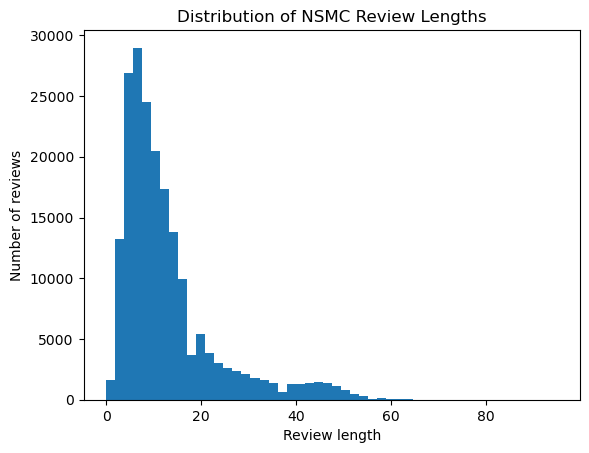

In [19]:
import numpy as np
import matplotlib.pyplot as plt

total_data_text = list(X_train) + list(X_test)

num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print("문장 길이 평균:", np.mean(num_tokens))
print("문장 길이 최대:", np.max(num_tokens))
print("문장 길이 표준편차:", np.std(num_tokens))

max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)

print("설정할 maxlen:", maxlen)
print("전체 문장의 {:.2f}%가 maxlen 안에 포함됩니다.".format(
    np.sum(num_tokens < max_tokens) / len(num_tokens) * 100
))

plt.hist(num_tokens, bins=50)
plt.xlabel("Review length")
plt.ylabel("Number of reviews")
plt.title("Distribution of NSMC Review Lengths")
plt.show()

## 문장 길이 분석

모델에 텍스트 데이터를 입력하기 위해서는 모든 리뷰 문장의 길이를 동일하게 맞추어야 한다.  
NSMC 리뷰 데이터는 문장마다 길이가 다르기 때문에, 먼저 전체 리뷰의 토큰 길이 분포를 확인하였다.

문장 길이의 평균과 표준편차를 확인한 뒤, `평균 + 2 * 표준편차`를 기준으로 `maxlen`을 설정하였다.  
이렇게 하면 대부분의 문장을 포함하면서도 지나치게 긴 문장 때문에 불필요한 패딩이 늘어나는 것을 줄일 수 있다.

In [20]:
def pad_sequences_pre(data, maxlen, pad_value=0):
    padded_data = []

    for sentence in data:
        if len(sentence) < maxlen:
            sentence = [pad_value] * (maxlen - len(sentence)) + sentence
        else:
            sentence = sentence[-maxlen:]

        padded_data.append(sentence)

    return np.array(padded_data)

X_train_padded = pad_sequences_pre(
    X_train,
    maxlen=maxlen,
    pad_value=word_to_index['<PAD>']
)

X_test_padded = pad_sequences_pre(
    X_test,
    maxlen=maxlen,
    pad_value=word_to_index['<PAD>']
)

print("X_train_padded shape:", X_train_padded.shape)
print("X_test_padded shape:", X_test_padded.shape)

X_train_padded shape: (146182, 33)
X_test_padded shape: (49157, 33)


In [21]:
print("패딩 전 첫 번째 리뷰:")
print(X_train[0])

print("\n패딩 후 첫 번째 리뷰:")
print(X_train_padded[0])

print("\n패딩 후 길이:")
print(len(X_train_padded[0]))
print("maxlen:", maxlen)

패딩 전 첫 번째 리뷰:
[49, 451, 6, 16, 7140, 670]

패딩 후 첫 번째 리뷰:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0   49
  451    6   16 7140  670]

패딩 후 길이:
33
maxlen: 33


## 패딩 적용

리뷰 문장은 길이가 모두 다르기 때문에 모델에 바로 입력할 수 없다.  
따라서 `maxlen`을 기준으로 모든 리뷰의 길이를 동일하게 맞추었다.

짧은 문장은 `<PAD>` 토큰인 0으로 앞쪽을 채웠고, 긴 문장은 뒤쪽 정보가 남도록 앞부분을 잘라냈다.  
이번 실습에서는 문장의 뒤쪽 단어 정보를 보존하기 위해 `pre-padding` 방식을 사용하였다.

In [22]:
x_val = X_train_padded[:30000]
y_val = y_train[:30000]

partial_x_train = X_train_padded[30000:]
partial_y_train = y_train[30000:]

print("partial_x_train:", partial_x_train.shape)
print("partial_y_train:", partial_y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("X_test_padded:", X_test_padded.shape)
print("y_test:", y_test.shape)

partial_x_train: (116182, 33)
partial_y_train: (116182,)
x_val: (30000, 33)
y_val: (30000,)
X_test_padded: (49157, 33)
y_test: (49157,)


## Validation set 구성

모델을 학습할 때 훈련 데이터만 사용하면, 모델이 훈련 데이터에만 지나치게 맞춰지는 과적합 여부를 확인하기 어렵다.  
따라서 훈련 데이터 일부를 validation set으로 분리하여 학습 과정에서 성능을 확인하였다.

최종 성능 평가는 별도로 보관한 test set을 사용한다.

In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size = 512

train_dataset = TensorDataset(
    torch.tensor(partial_x_train, dtype=torch.long),
    torch.tensor(partial_y_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_padded, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)
print("train batch 개수:", len(train_loader))
print("val batch 개수:", len(val_loader))
print("test batch 개수:", len(test_loader))

사용 device: cuda
train batch 개수: 227
val batch 개수: 59
test batch 개수: 97


## DataLoader 구성

PyTorch 모델은 데이터를 한 번에 모두 학습하지 않고, 일정한 크기의 batch 단위로 나누어 학습한다.  
이를 위해 `TensorDataset`과 `DataLoader`를 사용하여 train, validation, test 데이터를 배치 단위로 구성하였다.

입력 데이터는 단어 인덱스이므로 `torch.long` 타입을 사용하고, 라벨은 이진 분류 계산을 위해 `torch.float32` 타입으로 변환하였다.

다음 순서 진행 과정

1. 공통 학습 함수 만들기
2. 공통 평가 함수 만들기
3. 1-D CNN 모델 만들기
4. CNN 학습 실행
5. CNN test accuracy 확인
6. 그래프 그리기
7. 다음 모델로 넘어가기

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(model, train_loader, val_loader, epochs=5, lr=0.001):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()

        train_loss_total = 0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * inputs.size(0)

            preds = (outputs > 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss_total / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs).squeeze()
                loss = loss_fn(outputs, labels)

                val_loss_total += loss.item() * inputs.size(0)

                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} - "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return model, history

모델이 달라져도 같은 방식으로 학습할 수 있도록 공통 학습 함수를 만든다.

In [25]:
def evaluate_model(model, test_loader):
    model.eval()
    loss_fn = nn.BCELoss()

    test_loss_total = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)

            test_loss_total += loss.item() * inputs.size(0)

            preds = (outputs > 0.5).float()
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_total / test_total
    test_acc = test_correct / test_total

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    return test_loss, test_acc

학습이 끝난 모델을 test 데이터로 최종 평가하는 함수를 만든다.

In [27]:
import torch.nn.functional as F

vocab_size = 10000
word_vector_dim = 128

class NSMCCNNTextModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=0
        )

        self.conv1 = nn.Conv1d(
            in_channels=word_vector_dim,
            out_channels=128,
            kernel_size=7,
            padding=3
        )

        self.conv2 = nn.Conv1d(
            in_channels=128,
            out_channels=128,
            kernel_size=7,
            padding=3
        )

        self.global_max_pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        x = self.embedding(x)
        # x shape: (batch_size, sequence_length, embedding_dim)

        x = x.permute(0, 2, 1)
        # Conv1D는 (batch_size, embedding_dim, sequence_length)를 입력으로 받음

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = self.global_max_pool(x).squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))

        return x

1-D CNN은 문장 안에서 감정을 드러내는 짧은 표현 패턴을 잡아내는 모델이다.

In [28]:
model_cnn = NSMCCNNTextModel(vocab_size, word_vector_dim)
print(model_cnn)

NSMCCNNTextModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (conv1): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [29]:
model_cnn, history_cnn = train_model(
    model_cnn,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.001
)

Epoch 1/5 - Train Loss: 0.5316, Train Acc: 0.7202 - Val Loss: 0.4287, Val Acc: 0.7970
Epoch 2/5 - Train Loss: 0.3861, Train Acc: 0.8257 - Val Loss: 0.3804, Val Acc: 0.8235
Epoch 3/5 - Train Loss: 0.3150, Train Acc: 0.8652 - Val Loss: 0.3735, Val Acc: 0.8319
Epoch 4/5 - Train Loss: 0.2555, Train Acc: 0.8952 - Val Loss: 0.3945, Val Acc: 0.8325
Epoch 5/5 - Train Loss: 0.1942, Train Acc: 0.9229 - Val Loss: 0.4441, Val Acc: 0.8272


In [30]:
cnn_test_loss, cnn_test_acc = evaluate_model(model_cnn, test_loader)

Test Loss: 0.4618
Test Accuracy: 0.8211


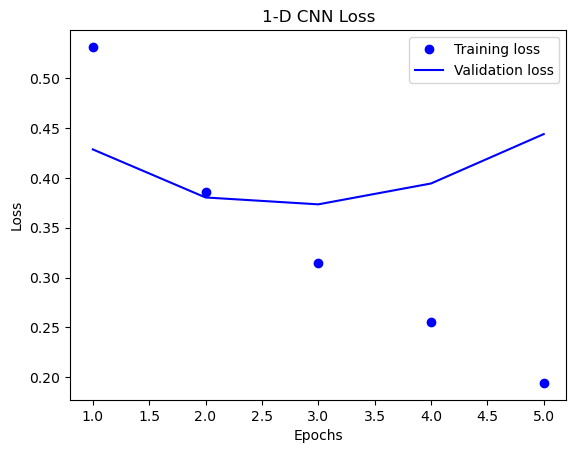

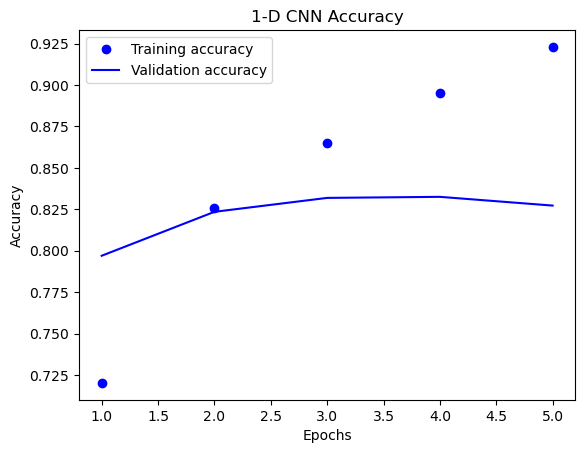

In [31]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs_range, history["train_loss"], "bo", label="Training loss")
    plt.plot(epochs_range, history["val_loss"], "b", label="Validation loss")
    plt.title(title + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs_range, history["train_acc"], "bo", label="Training accuracy")
    plt.plot(epochs_range, history["val_acc"], "b", label="Validation accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_cnn, "1-D CNN")

loss와 accuracy 그래프를 통해 학습이 잘 진행됐는지 확인한다.

## 1-D CNN 모델 실험

첫 번째 모델로 1-D CNN을 구성하였다.  
1-D CNN은 문장을 순서대로 하나씩 기억하는 방식이 아니라, 문장 안에서 감정을 나타내는 지역적 표현 패턴을 찾는 방식으로 동작한다.

예를 들어 “진짜 재밌다”, “완전 별로”, “시간 아깝다”와 같은 짧은 표현들이 감성 분류에 중요한 단서가 될 수 있다.  
CNN은 이러한 표현 패턴을 convolution 연산을 통해 추출하고, Global Max Pooling을 통해 가장 강한 특징을 선택한다.

이번 실험에서는 Embedding 층, Conv1D 층 2개, Global Max Pooling, Dense 층을 사용하여 긍정/부정 이진 분류를 수행하였다.

1-D CNN 모델은 4 epoch 부근에서 가장 높은 validation accuracy를 보였고, 이후 validation accuracy가 소폭 하락하였다. 이는 학습이 진행되면서 train accuracy는 계속 상승하지만 validation 성능은 더 이상 개선되지 않는 과적합 경향으로 해석할 수 있다.

두 번째 모델: GlobalMaxPooling 모델

1. GlobalMaxPooling 모델 학습
2. GlobalMaxPooling test accuracy 확인
3. LSTM 모델 학습
4. LSTM test accuracy 확인
5. 결과표 만들기
6. CNN 개선 실험 또는 Word2Vec 적용

In [32]:
class NSMCGlobalMaxPoolModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=0
        )

        self.fc1 = nn.Linear(word_vector_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        x = self.embedding(x)
        # x shape: (batch_size, sequence_length, embedding_dim)

        x = torch.max(x, dim=1).values
        # 문장 전체에서 가장 강하게 반응한 특징만 선택

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))

        return x

GlobalMaxPooling 모델은 문장 전체에서 가장 강한 감성 단서를 뽑아 긍정/부정을 분류한다.

In [33]:
model_gmp = NSMCGlobalMaxPoolModel(vocab_size, word_vector_dim)
print(model_gmp)

NSMCGlobalMaxPoolModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [34]:
model_gmp, history_gmp = train_model(
    model_gmp,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.001
)

Epoch 1/5 - Train Loss: 0.6576, Train Acc: 0.5992 - Val Loss: 0.5826, Val Acc: 0.7015
Epoch 2/5 - Train Loss: 0.5398, Train Acc: 0.7286 - Val Loss: 0.4830, Val Acc: 0.7672
Epoch 3/5 - Train Loss: 0.4620, Train Acc: 0.7821 - Val Loss: 0.4391, Val Acc: 0.7934
Epoch 4/5 - Train Loss: 0.4177, Train Acc: 0.8104 - Val Loss: 0.4160, Val Acc: 0.8045
Epoch 5/5 - Train Loss: 0.3865, Train Acc: 0.8284 - Val Loss: 0.4025, Val Acc: 0.8134


In [35]:
gmp_test_loss, gmp_test_acc = evaluate_model(model_gmp, test_loader)

Test Loss: 0.4149
Test Accuracy: 0.8068


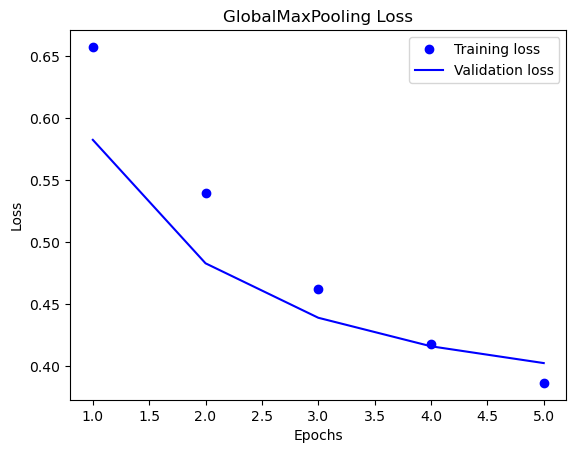

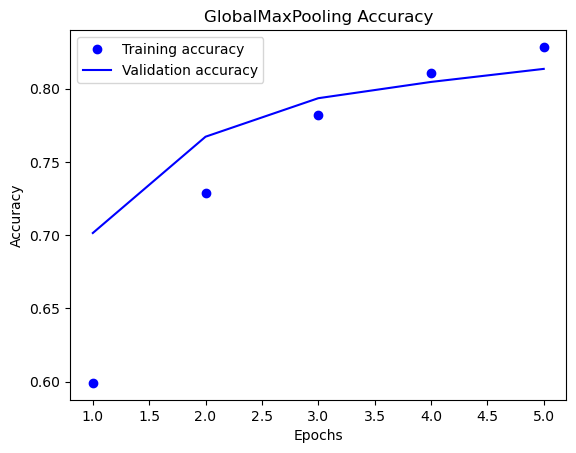

In [36]:
plot_history(history_gmp, "GlobalMaxPooling")

GlobalMaxPooling 모델은 학습이 진행될수록 validation accuracy가 꾸준히 상승하였다.  
최종 Test Accuracy는 0.8068로 나타났으며, 1-D CNN보다는 낮은 성능을 보였다.  
이는 GlobalMaxPooling 모델이 문장 전체에서 가장 강한 특징만 선택하기 때문에 구조가 단순하고 빠르지만, 단어 순서나 복잡한 문맥을 충분히 반영하기 어렵기 때문으로 해석할 수 있다.

## LSTM 모델 실험

세 번째 모델로 LSTM을 구성하였다.  
LSTM은 RNN 계열 모델로, 문장을 앞에서 뒤로 읽으면서 이전 단어의 정보를 hidden state에 저장한다.

텍스트는 단어의 순서가 중요한 시퀀스 데이터이기 때문에 LSTM은 감성분석에 자주 사용된다.  
예를 들어 “재미있다”와 “재미없다”처럼 비슷한 단어가 포함되어도 문맥과 순서에 따라 감성이 달라질 수 있으므로, 순차 정보를 반영하는 모델이 필요하다.

이번 실험에서는 Embedding 층, LSTM 층, Dense 층을 사용하여 긍정/부정 이진 분류를 수행하였다.

In [37]:
class NSMCLSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_dim=64):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=word_vector_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        x = hidden[-1]

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))

        return x

In [38]:
model_lstm = NSMCLSTMModel(vocab_size, word_vector_dim)
print(model_lstm)

NSMCLSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [39]:
model_lstm, history_lstm = train_model(
    model_lstm,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.001
)

Epoch 1/5 - Train Loss: 0.5413, Train Acc: 0.7149 - Val Loss: 0.4208, Val Acc: 0.8049
Epoch 2/5 - Train Loss: 0.3919, Train Acc: 0.8244 - Val Loss: 0.3760, Val Acc: 0.8269
Epoch 3/5 - Train Loss: 0.3408, Train Acc: 0.8528 - Val Loss: 0.3659, Val Acc: 0.8348
Epoch 4/5 - Train Loss: 0.3074, Train Acc: 0.8696 - Val Loss: 0.3582, Val Acc: 0.8382
Epoch 5/5 - Train Loss: 0.2788, Train Acc: 0.8842 - Val Loss: 0.3637, Val Acc: 0.8392


In [40]:
lstm_test_loss, lstm_test_acc = evaluate_model(model_lstm, test_loader)

Test Loss: 0.3747
Test Accuracy: 0.8347


plot_history(history_lstm, "LSTM")

다음 진행하는 과정
    
1. 모델 3개 결과표 만들기
2. LSTM 결과 해석 마크다운 작성
3. 85% 달성을 위한 개선 실험 1개 진행
4. Word2Vec 파일 존재 여부 확인
5. 가능하면 Word2Vec 적용
6. 최종 README 정리

In [43]:
import pandas as pd

result_df = pd.DataFrame({
    "Model": ["1-D CNN", "GlobalMaxPooling", "LSTM"],
    "Test Loss": [cnn_test_loss, gmp_test_loss, lstm_test_loss],
    "Test Accuracy": [cnn_test_acc, gmp_test_acc, lstm_test_acc]
})

result_df

,Model,Test Loss,Test Accuracy
0,1-D CNN,0.461812,0.821124
1,GlobalMaxPooling,0.414915,0.806803
2,LSTM,0.374652,0.834652


In [44]:
class NSMCLSTMModelV2(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_vector_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=word_vector_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        x = hidden[-1]

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))

        return x

In [45]:
model_lstm_v2 = NSMCLSTMModelV2(vocab_size, word_vector_dim)
print(model_lstm_v2)

NSMCLSTMModelV2(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [46]:
model_lstm_v2, history_lstm_v2 = train_model(
    model_lstm_v2,
    train_loader,
    val_loader,
    epochs=6,
    lr=0.001
)

Epoch 1/6 - Train Loss: 0.5163, Train Acc: 0.7338 - Val Loss: 0.4103, Val Acc: 0.8089
Epoch 2/6 - Train Loss: 0.3761, Train Acc: 0.8309 - Val Loss: 0.3658, Val Acc: 0.8343
Epoch 3/6 - Train Loss: 0.3245, Train Acc: 0.8576 - Val Loss: 0.3562, Val Acc: 0.8396
Epoch 4/6 - Train Loss: 0.2922, Train Acc: 0.8750 - Val Loss: 0.3515, Val Acc: 0.8466
Epoch 5/6 - Train Loss: 0.2598, Train Acc: 0.8915 - Val Loss: 0.3602, Val Acc: 0.8449
Epoch 6/6 - Train Loss: 0.2295, Train Acc: 0.9049 - Val Loss: 0.3898, Val Acc: 0.8419


Test Loss: 0.4068
Test Accuracy: 0.8354


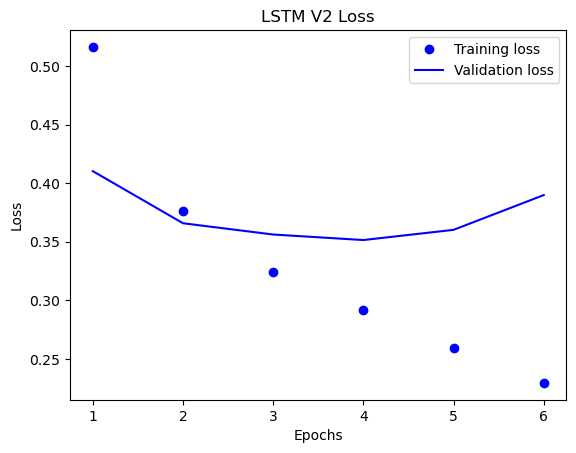

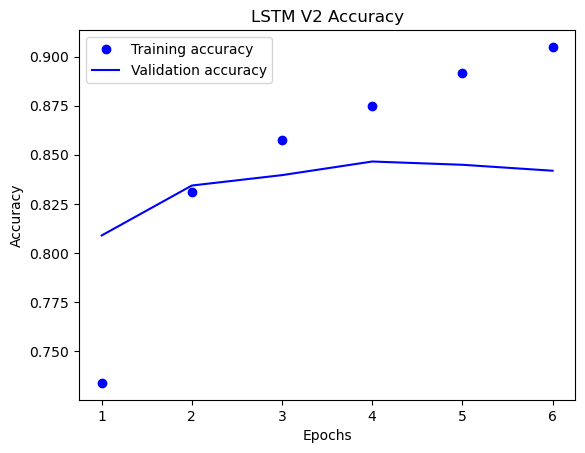

In [47]:
lstm_v2_test_loss, lstm_v2_test_acc = evaluate_model(model_lstm_v2, test_loader)
plot_history(history_lstm_v2, "LSTM V2")

In [48]:
print("LSTM V2 Test Loss:", lstm_v2_test_loss)
print("LSTM V2 Test Accuracy:", lstm_v2_test_acc)

LSTM V2 Test Loss: 0.4067704760252509
LSTM V2 Test Accuracy: 0.8353642411050308


In [49]:
import pandas as pd

result_df = pd.DataFrame({
    "Model": ["1-D CNN", "GlobalMaxPooling", "LSTM", "LSTM V2"],
    "Test Loss": [cnn_test_loss, gmp_test_loss, lstm_test_loss, lstm_v2_test_loss],
    "Test Accuracy": [cnn_test_acc, gmp_test_acc, lstm_test_acc, lstm_v2_test_acc]
})

result_df

,Model,Test Loss,Test Accuracy
0,1-D CNN,0.461812,0.821124
1,GlobalMaxPooling,0.414915,0.806803
2,LSTM,0.374652,0.834652
3,LSTM V2,0.406770,0.835364


## 모델별 실험 결과 비교

NSMC 네이버 영화리뷰 감성분석을 위해 1-D CNN, GlobalMaxPooling, LSTM, LSTM V2 총 4가지 모델을 실험하였다.

| 모델 | Test Loss | Test Accuracy |
|---|---:|---:|
| 1-D CNN | 0.4618 | 0.8211 |
| GlobalMaxPooling | 0.4149 | 0.8068 |
| LSTM | 0.3747 | 0.8347 |
| LSTM V2 | 0.4068 | 0.8354 |

실험 결과 LSTM V2 모델이 Test Accuracy 0.8354로 가장 높은 성능을 보였다.  
평가 기준인 85%에는 도달하지 못했지만, 4가지 모델을 비교하며 모델 구조별 성능 차이를 확인하였다.

In [50]:
import os

word2vec_ko_path = os.path.join(
    os.getenv("HOME"),
    "work/sentiment_classification/data/word2vec_ko.model"
)

print("word2vec_ko.model 존재:", os.path.exists(word2vec_ko_path))
print("경로:", word2vec_ko_path)

word2vec_ko.model 존재: False
경로: /home/jovyan/work/sentiment_classification/data/word2vec_ko.model


In [51]:
!find ~/work -name "word2vec_ko.model"
!find /home/jovyan -name "word2vec_ko.model"

## 한국어 Word2Vec 적용 여부 확인

과제에서는 한국어 사전학습 Word2Vec 모델인 `word2vec_ko.model`을 활용하도록 안내되어 있었다.  
이에 따라 `~/work/sentiment_classification/data/word2vec_ko.model` 경로에서 파일 존재 여부를 확인하였다.

확인 결과, 현재 실습 환경에서는 `word2vec_ko.model` 파일을 찾을 수 없었다.  
따라서 이번 실험에서는 사전학습 Word2Vec 임베딩을 직접 적용하지 못했고, 각 모델의 Embedding 층이 NSMC 데이터 학습 과정에서 자체적으로 단어 벡터를 학습하도록 구성하였다.

추후 `word2vec_ko.model` 파일이 제공되면, 해당 임베딩을 Embedding 층의 초기 가중치로 사용하여 자체 학습 Embedding과 사전학습 Embedding의 성능 차이를 비교할 수 있다.

In [52]:
embedding_layer = model_lstm_v2.embedding
embedding_weights = embedding_layer.weight.detach().cpu().numpy()

print("Embedding weight shape:", embedding_weights.shape)

Embedding weight shape: (10000, 128)


In [53]:
target_words = ["영화", "재미", "최고", "별로", "감동"]

for word in target_words:
    if word in word_to_index:
        idx = word_to_index[word]
        vector = embedding_weights[idx]
        print(f"{word} index:", idx)
        print(f"{word} vector 앞 10개 값:", vector[:10])
        print()
    else:
        print(f"{word}는 word_to_index에 없습니다.")

영화 index: 5
영화 vector 앞 10개 값: [ 0.05468391  0.73982495 -0.701392    0.6626677   1.8616526  -1.9319026
 -0.9413609  -0.54252887 -0.8924998  -0.82578725]

재미 index: 59
재미 vector 앞 10개 값: [-0.7935149  -0.9450813  -1.133515    0.6929549  -0.26447085  0.74044394
 -0.7126013  -0.27393115  1.1574122  -0.9892491 ]

최고 index: 26
최고 vector 앞 10개 값: [ 1.061748   -2.068453   -0.26024085 -0.51040584 -0.00769582 -0.4489451
  2.4182165  -2.3274221  -0.2683436   1.0516452 ]

별로 index: 122
별로 vector 앞 10개 값: [ 1.1484993   1.4991164  -0.21031377 -0.08930606  0.40043327  0.09143587
  0.20006534 -0.31021556 -0.57204086 -0.5039823 ]

감동 index: 40
감동 vector 앞 10개 값: [ 0.42489424  0.3600916   0.05275742  0.28905275  1.2033955  -0.03298892
 -1.1008184   0.49288303 -0.70761436 -0.5338918 ]



## 최종 회고

이번 프로젝트에서는 네이버 영화리뷰 NSMC 데이터를 활용하여 한국어 감성분석을 수행하였다.  
영화 리뷰 문장을 입력으로 받아 긍정 또는 부정 감성을 예측하는 이진 분류 문제로 접근하였다.

전처리 과정에서는 중복 리뷰와 결측치를 제거하고, 한국어 문장을 형태소 단위로 토큰화하였다.  
초기에는 Mecab 형태소 분석기를 사용하려 했으나, 현재 실습 환경에서 Mecab 사전 설치 문제가 발생하여 Okt 형태소 분석기로 대체하였다.  
Okt를 사용해 리뷰 문장을 토큰화한 뒤, 불용어를 제거하고 단어 사전을 구성하였다. 이후 각 리뷰를 정수 시퀀스로 변환하고, 패딩을 적용하여 모델 입력 형태를 통일하였다.

모델 실험에서는 1-D CNN, GlobalMaxPooling, LSTM, LSTM V2 총 4가지 모델을 비교하였다.  
실험 결과 LSTM V2 모델이 Test Accuracy 0.8354로 가장 높은 성능을 보였다.  
LSTM V2는 기존 LSTM보다 hidden dimension을 64에서 128로 늘리고 dropout을 0.5에서 0.3으로 조정한 모델이다.

Validation Accuracy는 4 epoch에서 가장 높았고 이후 소폭 하락하였다.  
이를 통해 모델의 표현력을 높이는 것이 성능 향상에 도움이 될 수 있지만, epoch가 지나치게 늘어나면 과적합이 발생할 수 있음을 확인하였다.

과제에서 요구한 한국어 사전학습 Word2Vec 모델인 `word2vec_ko.model`은 현재 실습 환경에서 찾을 수 없었다.  
따라서 이번 실험에서는 사전학습 Word2Vec 임베딩을 직접 적용하지 못했고, 가장 성능이 좋았던 LSTM V2 모델의 Embedding 층을 분석하였다.  
Embedding weight의 크기는 `(10000, 128)`로 확인되었으며, 이는 10000개의 단어가 각각 128차원 벡터로 표현되었음을 의미한다.

평가 기준인 85% 정확도에는 도달하지 못했지만, 4가지 모델을 실험하고 각 모델의 구조적 차이와 성능 차이를 비교할 수 있었다.  
추후에는 Mecab 설치 환경을 정상화하고, 사전학습 Word2Vec 임베딩을 적용하여 자체 학습 Embedding과 성능을 비교하는 추가 실험을 진행하고 싶다.

노트북에서 마지막으로 확인할 체크리스트

1. 프로젝트 소개 있음
2. 데이터 다운로드 및 불러오기 있음
3. Mecab 실패 → Okt 대체 설명 있음
4. 데이터 전처리 있음
5. 토큰화, 불용어 제거 있음
6. word_to_index 생성 있음
7. 문장 길이 분석 있음
8. 패딩 있음
9. DataLoader 구성 있음
10. 1-D CNN 실험 있음
11. GlobalMaxPooling 실험 있음
12. LSTM 실험 있음
13. LSTM V2 개선 실험 있음
14. Loss/Accuracy 그래프 있음
15. 결과표 있음
16. Word2Vec 파일 확인 있음
17. 자체 Embedding 분석 있음
18. 최종 회고 있음

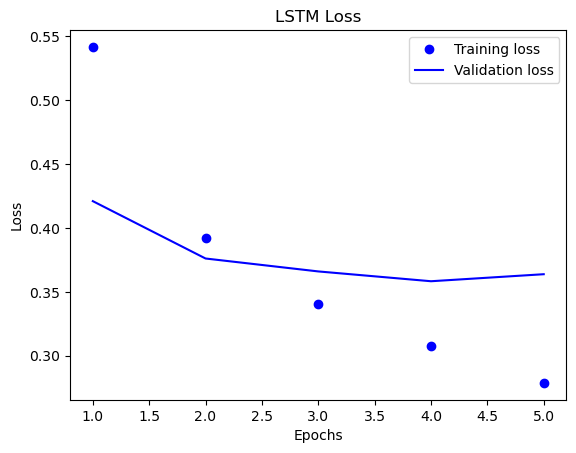

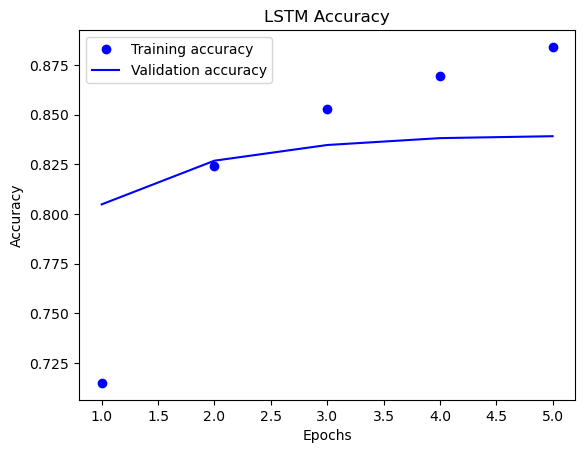

In [54]:
plot_history(history_lstm, "LSTM")